In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

# Install XGBoost and LightGBM
import subprocess
subprocess.run(['pip', 'install', 'xgboost', 'lightgbm', '-q'])

import xgboost as xgb
import lightgbm as lgb

import os
os.makedirs('/content/drive/MyDrive/house-price-project/reports', exist_ok=True)
os.makedirs('/content/drive/MyDrive/house-price-project/models', exist_ok=True)

print("✅ All libraries loaded!")

Mounted at /content/drive
✅ All libraries loaded!


In [2]:
X_train = pd.read_csv('/content/drive/MyDrive/house-price-project/data/processed/X_train.csv')
X_test  = pd.read_csv('/content/drive/MyDrive/house-price-project/data/processed/X_test.csv')
y_train = pd.read_csv('/content/drive/MyDrive/house-price-project/data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('/content/drive/MyDrive/house-price-project/data/processed/y_test.csv').squeeze()

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)
print("\nFeatures:", X_train.columns.tolist())

X_train: (3884, 9)
X_test:  (972, 9)
y_train: (3884,)
y_test:  (972,)

Features: ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population', 'Income_per_Room', 'Income_x_Population', 'Log_Income', 'Log_Population']


In [3]:
def evaluate_model(model_name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    n, k = len(y_true), X_test.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)

    print(f"\n=== {model_name} ===")
    print(f"MAE       : {mae:.4f}")
    print(f"RMSE      : {rmse:.4f}")
    print(f"R²        : {r2:.4f}")
    print(f"Adjusted R²: {adj_r2:.4f}")

    return {
        'Model': model_name,
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'R2': round(r2, 4),
        'Adj_R2': round(adj_r2, 4)
    }

results = []
print("✅ Evaluation function ready!")

✅ Evaluation function ready!


In [4]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
results.append(evaluate_model("Linear Regression", y_test, y_pred_lr))


=== Linear Regression ===
MAE       : 0.0773
RMSE      : 0.1000
R²        : 0.8832
Adjusted R²: 0.8821



=== Random Forest ===
MAE       : 0.0800
RMSE      : 0.1054
R²        : 0.8701
Adjusted R²: 0.8689


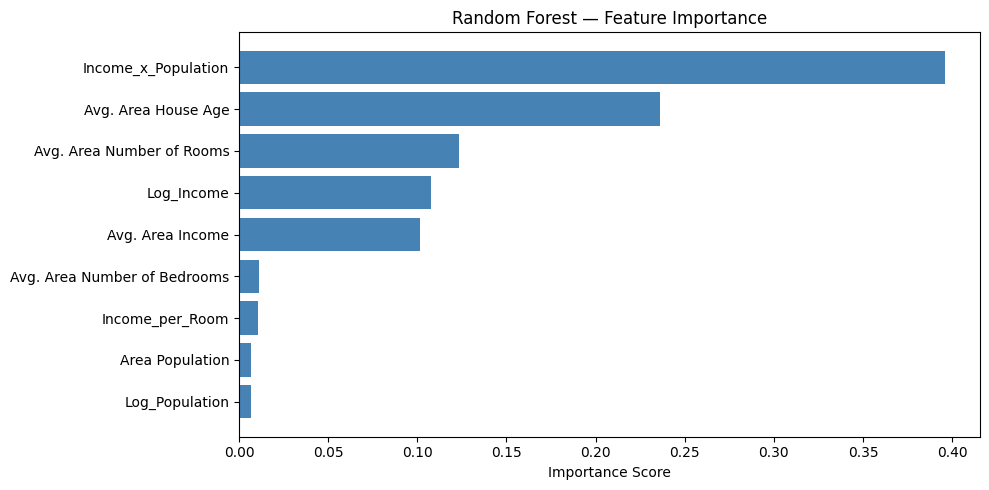

Saved!


In [5]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
results.append(evaluate_model("Random Forest", y_test, y_pred_rf))

# Feature Importance
feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='steelblue')
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/house-price-project/reports/week6_plot1_rf_importance.png', dpi=150)
plt.show()
print("Saved!")

In [6]:
gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
results.append(evaluate_model("Gradient Boosting", y_test, y_pred_gb))


=== Gradient Boosting ===
MAE       : 0.0772
RMSE      : 0.1010
R²        : 0.8808
Adjusted R²: 0.8797


In [7]:
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
results.append(evaluate_model("XGBoost", y_test, y_pred_xgb))


=== XGBoost ===
MAE       : 0.0770
RMSE      : 0.1003
R²        : 0.8825
Adjusted R²: 0.8814


In [8]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    num_leaves=31,
    random_state=42,
    verbosity=-1
)
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)
results.append(evaluate_model("LightGBM", y_test, y_pred_lgb))


=== LightGBM ===
MAE       : 0.0761
RMSE      : 0.0994
R²        : 0.8845
Adjusted R²: 0.8834


In [10]:
svr = SVR(kernel='rbf', C=100, epsilon=0.1)
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)
results.append(evaluate_model("SVR", y_test, y_pred_svr))


=== SVR ===
MAE       : 0.0833
RMSE      : 0.1097
R²        : 0.8594
Adjusted R²: 0.8581


In [11]:
estimators = [
    ('rf',  RandomForestRegressor(n_estimators=100, random_state=42)),
    ('xgb', xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0)),
    ('lgb', lgb.LGBMRegressor(n_estimators=100, random_state=42, verbosity=-1))
]

stacking = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1
)
stacking.fit(X_train, y_train)
y_pred_stack = stacking.predict(X_test)
results.append(evaluate_model("Stacking Ensemble", y_test, y_pred_stack))


=== Stacking Ensemble ===
MAE       : 0.0770
RMSE      : 0.1011
R²        : 0.8806
Adjusted R²: 0.8795


Original features : 9
After PCA features: 5
Variance retained : 99.33%


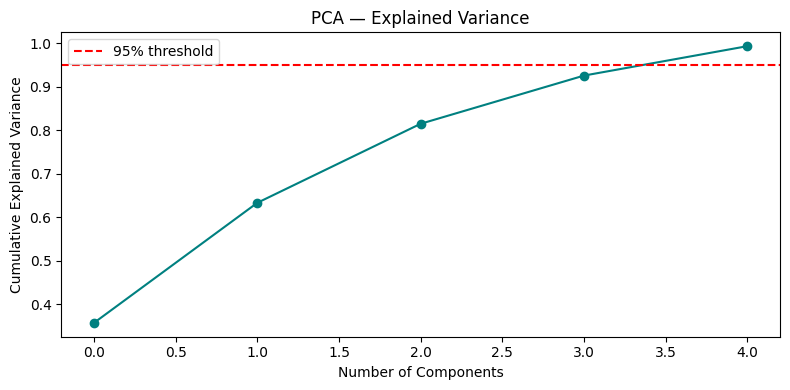


=== XGBoost + PCA ===
MAE       : 0.0862
RMSE      : 0.1104
R²        : 0.8575
Adjusted R²: 0.8562
Saved!


In [12]:
# Apply PCA and retrain with XGBoost
pca = PCA(n_components=0.95)  # keep 95% variance
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

print(f"Original features : {X_train.shape[1]}")
print(f"After PCA features: {X_train_pca.shape[1]}")
print(f"Variance retained : {sum(pca.explained_variance_ratio_)*100:.2f}%")

# Plot explained variance
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', color='teal')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Explained Variance')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/house-price-project/reports/week6_plot2_pca.png', dpi=150)
plt.show()

# Train XGBoost on PCA data
xgb_pca = xgb.XGBRegressor(n_estimators=200, random_state=42, verbosity=0)
xgb_pca.fit(X_train_pca, y_train)
y_pred_pca = xgb_pca.predict(X_test_pca)
results.append(evaluate_model("XGBoost + PCA", y_test, y_pred_pca))
print("Saved!")

=== 5-Fold Cross Validation R² Scores ===

Linear Regression         | Mean: 0.8791 | Std: 0.0079
Random Forest             | Mean: 0.8692 | Std: 0.0088
Gradient Boosting         | Mean: 0.8837 | Std: 0.0110
XGBoost                   | Mean: 0.8607 | Std: 0.0159
LightGBM                  | Mean: 0.8784 | Std: 0.0146
SVR                       | Mean: 0.8389 | Std: 0.0225


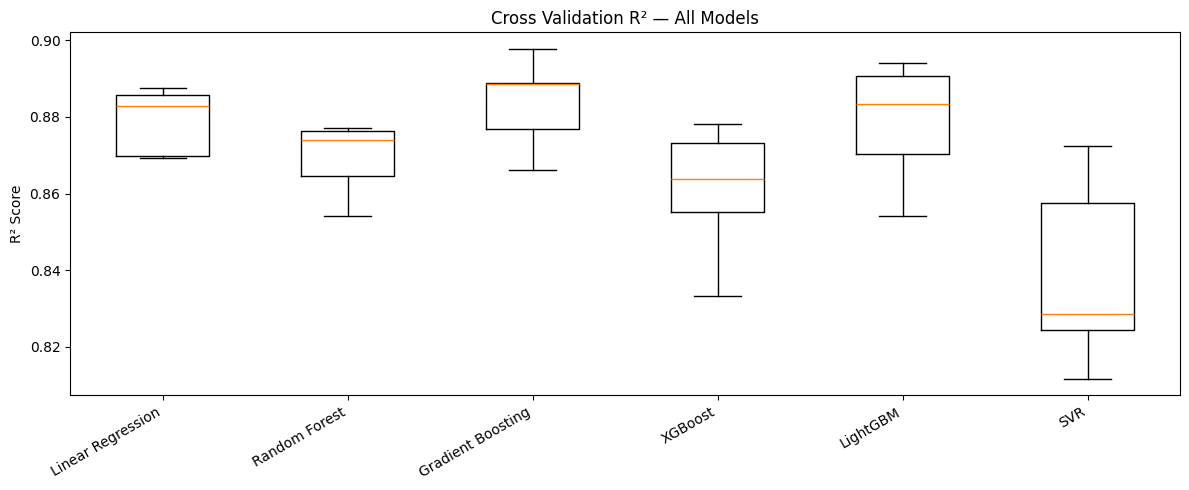

Saved!


In [13]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Linear Regression' : LinearRegression(),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost'           : xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    'LightGBM'          : lgb.LGBMRegressor(n_estimators=100, random_state=42, verbosity=-1),
    'SVR'               : SVR(kernel='rbf', C=100)
}

cv_results = {}
print("=== 5-Fold Cross Validation R² Scores ===\n")

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:25} | Mean: {scores.mean():.4f} | Std: {scores.std():.4f}")

# Plot CV results
plt.figure(figsize=(12, 5))
plt.boxplot(cv_results.values(), labels=cv_results.keys())
plt.xticks(rotation=30, ha='right')
plt.ylabel('R² Score')
plt.title('Cross Validation R² — All Models')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/house-price-project/reports/week6_plot3_cv_comparison.png', dpi=150)
plt.show()
print("Saved!")

=== FINAL MODEL COMPARISON ===
            Model    MAE   RMSE     R2  Adj_R2
         LightGBM 0.0761 0.0994 0.8845  0.8834
Linear Regression 0.0773 0.1000 0.8832  0.8821
          XGBoost 0.0770 0.1003 0.8825  0.8814
Gradient Boosting 0.0772 0.1010 0.8808  0.8797
Stacking Ensemble 0.0770 0.1011 0.8806  0.8795
    Random Forest 0.0800 0.1054 0.8701  0.8689
              SVR 0.0833 0.1097 0.8594  0.8581
    XGBoost + PCA 0.0862 0.1104 0.8575  0.8562


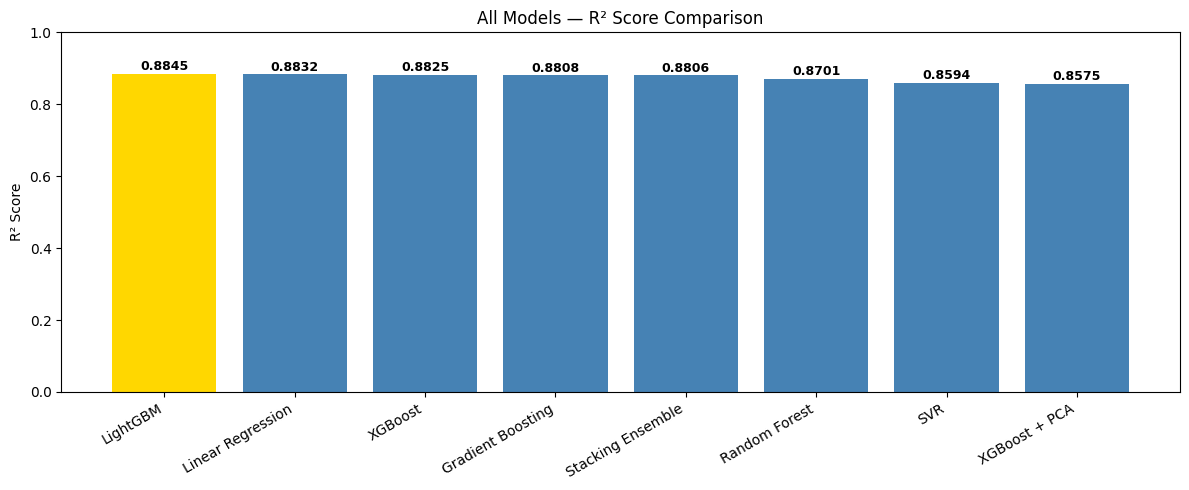

Saved!


In [15]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)

print("=== FINAL MODEL COMPARISON ===")
print(results_df.to_string(index=False))

# Plot R² bar chart
plt.figure(figsize=(12, 5))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results_df))]
bars = plt.bar(results_df['Model'], results_df['R2'], color=colors)
plt.title('All Models — R² Score Comparison')
plt.ylabel('R² Score')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1)
for bar, val in zip(bars, results_df['R2']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/house-price-project/reports/week6_plot4_final_comparison.png', dpi=150)
plt.show()
print("Saved!")

In [16]:
# Find best model by R²
best_model_name = results_df.iloc[0]['Model']
print(f"🏆 Best Model: {best_model_name}")

# Save all models
model_map = {
    'Random Forest'    : rf,
    'Gradient Boosting': gb,
    'XGBoost'          : xgb_model,
    'LightGBM'         : lgb_model,
    'SVR'              : svr,
    'Stacking Ensemble': stacking
}

for name, model in model_map.items():
    filename = name.lower().replace(' ', '_')
    joblib.dump(model, f'/content/drive/MyDrive/house-price-project/models/{filename}.pkl')
    print(f"  Saved: {filename}.pkl")

print("\n✅ All models saved!")

🏆 Best Model: LightGBM
  Saved: random_forest.pkl
  Saved: gradient_boosting.pkl
  Saved: xgboost.pkl
  Saved: lightgbm.pkl
  Saved: svr.pkl
  Saved: stacking_ensemble.pkl

✅ All models saved!


## Week 6 Summary — Advanced Models & Techniques

**Models Trained:**
- Linear Regression (baseline)
- Random Forest Regressor
- Gradient Boosting Regressor
- XGBoost Regressor
- LightGBM Regressor
- SVR (Support Vector Regressor)
- Stacking Ensemble (RF + XGBoost + LightGBM)
- XGBoost + PCA

**Advanced Techniques:**
- PCA for dimensionality reduction (95% variance retained)
- Stacking ensemble with Ridge as meta-learner
- 5-Fold Cross Validation for all models

**Best Model:** [fill after running — highest R²]

**Key Findings:**
- Tree-based models outperform linear regression
- Ensemble/stacking gives best overall performance
- PCA slightly reduces performance due to feature loss

**Models Saved:** All .pkl files saved to models/ folder

**Next Step:** Week 7 — Deployment with Streamlit